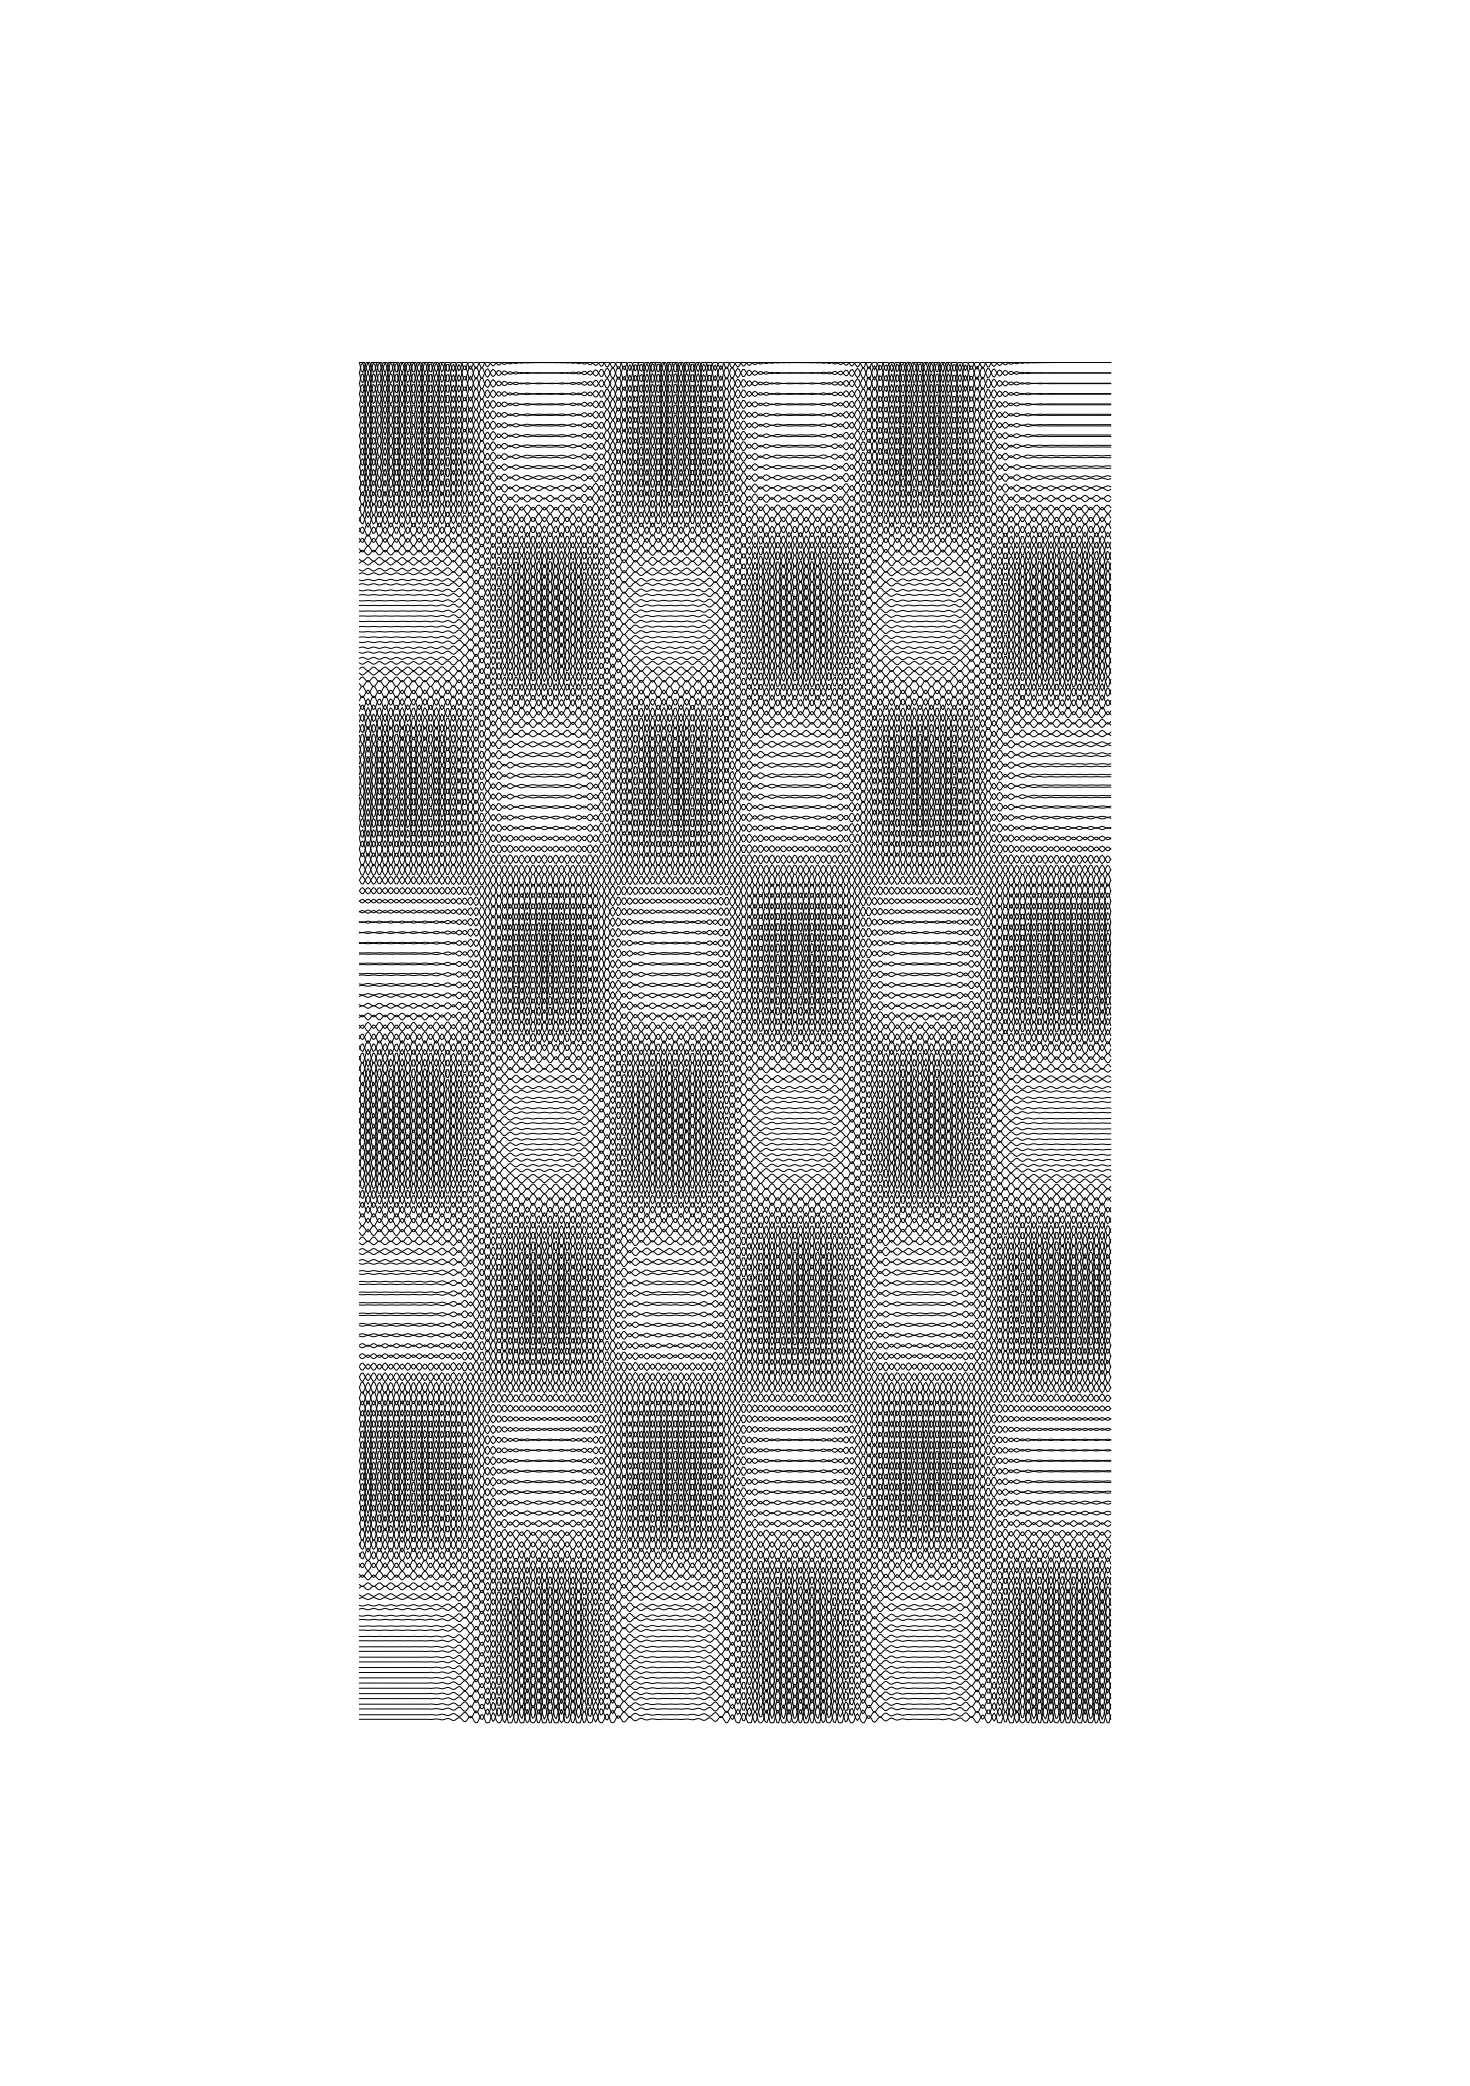

SVGs saved to: 07_moire/layer1_wavy.svg and 07_moire/layer2_wavy.svg


In [16]:
# Two full-page line patterns whose overlay reveals an image via moiré
# Uses a synthetic test image (checkerboard + Gaussian blur) from scipy.ndimage
# Saves SVGs into ./07_moire and shows a matplotlib preview.

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# -----------------------------
# Synthetic "hidden" image
# -----------------------------
H_img, W_img = 200, 150
yy, xx = np.mgrid[0:H_img, 0:W_img]
checker = ((xx // 25 + yy // 25) % 2).astype(float)  # checkerboard
img = ndimage.gaussian_filter(checker, sigma=5)      # smooth it
img = (img - img.min()) / (img.max() - img.min())    # normalize 0..1

# -----------------------------
# Page and output
# -----------------------------
W_mm, H_mm = 210.0, 297.0
margin_mm = 50.0
outdir = "07_moire"
os.makedirs(outdir, exist_ok=True)

# -----------------------------
# Line and moiré parameters
# -----------------------------
spacing_mm = 1.5
eps = 0.02
A_mm = 1.5
fx_per_mm = 0.6
stroke_mm = 0.18
samples_per_mm = 4

s1 = spacing_mm
s2 = spacing_mm * (1.0 + eps)
x_min, x_max = margin_mm, W_mm - margin_mm
y_min, y_max = margin_mm, H_mm - margin_mm

# -----------------------------
# SVG helpers
# -----------------------------
def svg_preamble(w_mm, h_mm):
    return (
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{w_mm}mm" height="{h_mm}mm" '
        f'viewBox="0 0 {w_mm} {h_mm}">\n'
        f'  <rect x="0" y="0" width="{w_mm}" height="{h_mm}" fill="white"/>\n'
    )
def svg_footer():
    return '</svg>\n'
def polyline_tag(xs, ys, sw=stroke_mm, color="black"):
    pts = " ".join([f"{x:.2f},{y:.2f}" for x, y in zip(xs, ys)])
    return f'  <polyline fill="none" stroke="{color}" stroke-width="{sw:.3f}" points="{pts}"/>\n'

# -----------------------------
# Image sampling function
# -----------------------------
def sample_image_mm(x_mm_array, y_mm_scalar):
    col = np.clip(((x_mm_array - x_min) / (x_max - x_min)) * (W_img - 1), 0, W_img - 1)
    row = np.clip(((y_mm_scalar - y_min) / (y_max - y_min)) * (H_img - 1), 0, H_img - 1)
    r = int(round(row))
    c0 = np.floor(col).astype(int)
    c1 = np.clip(c0 + 1, 0, W_img - 1)
    t = col - c0
    return (1 - t) * img[r, c0] + t * img[r, c1]

# -----------------------------
# Make layers
# -----------------------------
def make_layer(spacing, sign):
    xs = np.linspace(x_min, x_max, int(np.ceil((x_max-x_min) * samples_per_mm)))
    y_lines = np.arange(y_min, y_max + 1e-9, spacing)
    polylines = []
    for y0 in y_lines:
        a = 1.0 - sample_image_mm(xs, y0)  # invert so dark = dark reveal
        wobble = sign * A_mm * a * np.sin(2*np.pi*fx_per_mm*(xs - x_min))
        ys = np.clip(y0 + wobble, y_min, y_max)
        polylines.append((xs, ys))
    return polylines

layer1 = make_layer(s1, +1.0)
layer2 = make_layer(s2, -1.0)

# -----------------------------
# Save SVGs
# -----------------------------
f1 = os.path.join(outdir, "layer1_wavy.svg")
f2 = os.path.join(outdir, "layer2_wavy.svg")

with open(f1, "w") as f:
    f.write(svg_preamble(W_mm, H_mm))
    for xs, ys in layer1:
        f.write(polyline_tag(xs, ys))
    f.write(svg_footer())

with open(f2, "w") as f:
    f.write(svg_preamble(W_mm, H_mm))
    for xs, ys in layer2:
        f.write(polyline_tag(xs, ys))
    f.write(svg_footer())

# -----------------------------
# Preview overlay
# -----------------------------
fig_w_in = W_mm / 25.4
fig_h_in = H_mm / 25.4
plt.figure(figsize=(fig_w_in, fig_h_in), dpi=180)
for xs, ys in layer2:
    plt.plot(xs, ys, linewidth=0.4, color="black")
for xs, ys in layer1:
    plt.plot(xs, ys, linewidth=0.4, color="black")
plt.xlim(0, W_mm)
plt.ylim(H_mm, 0)
plt.axis("off")
plt.tight_layout()
plt.show()

print("SVGs saved to:", f1, "and", f2)


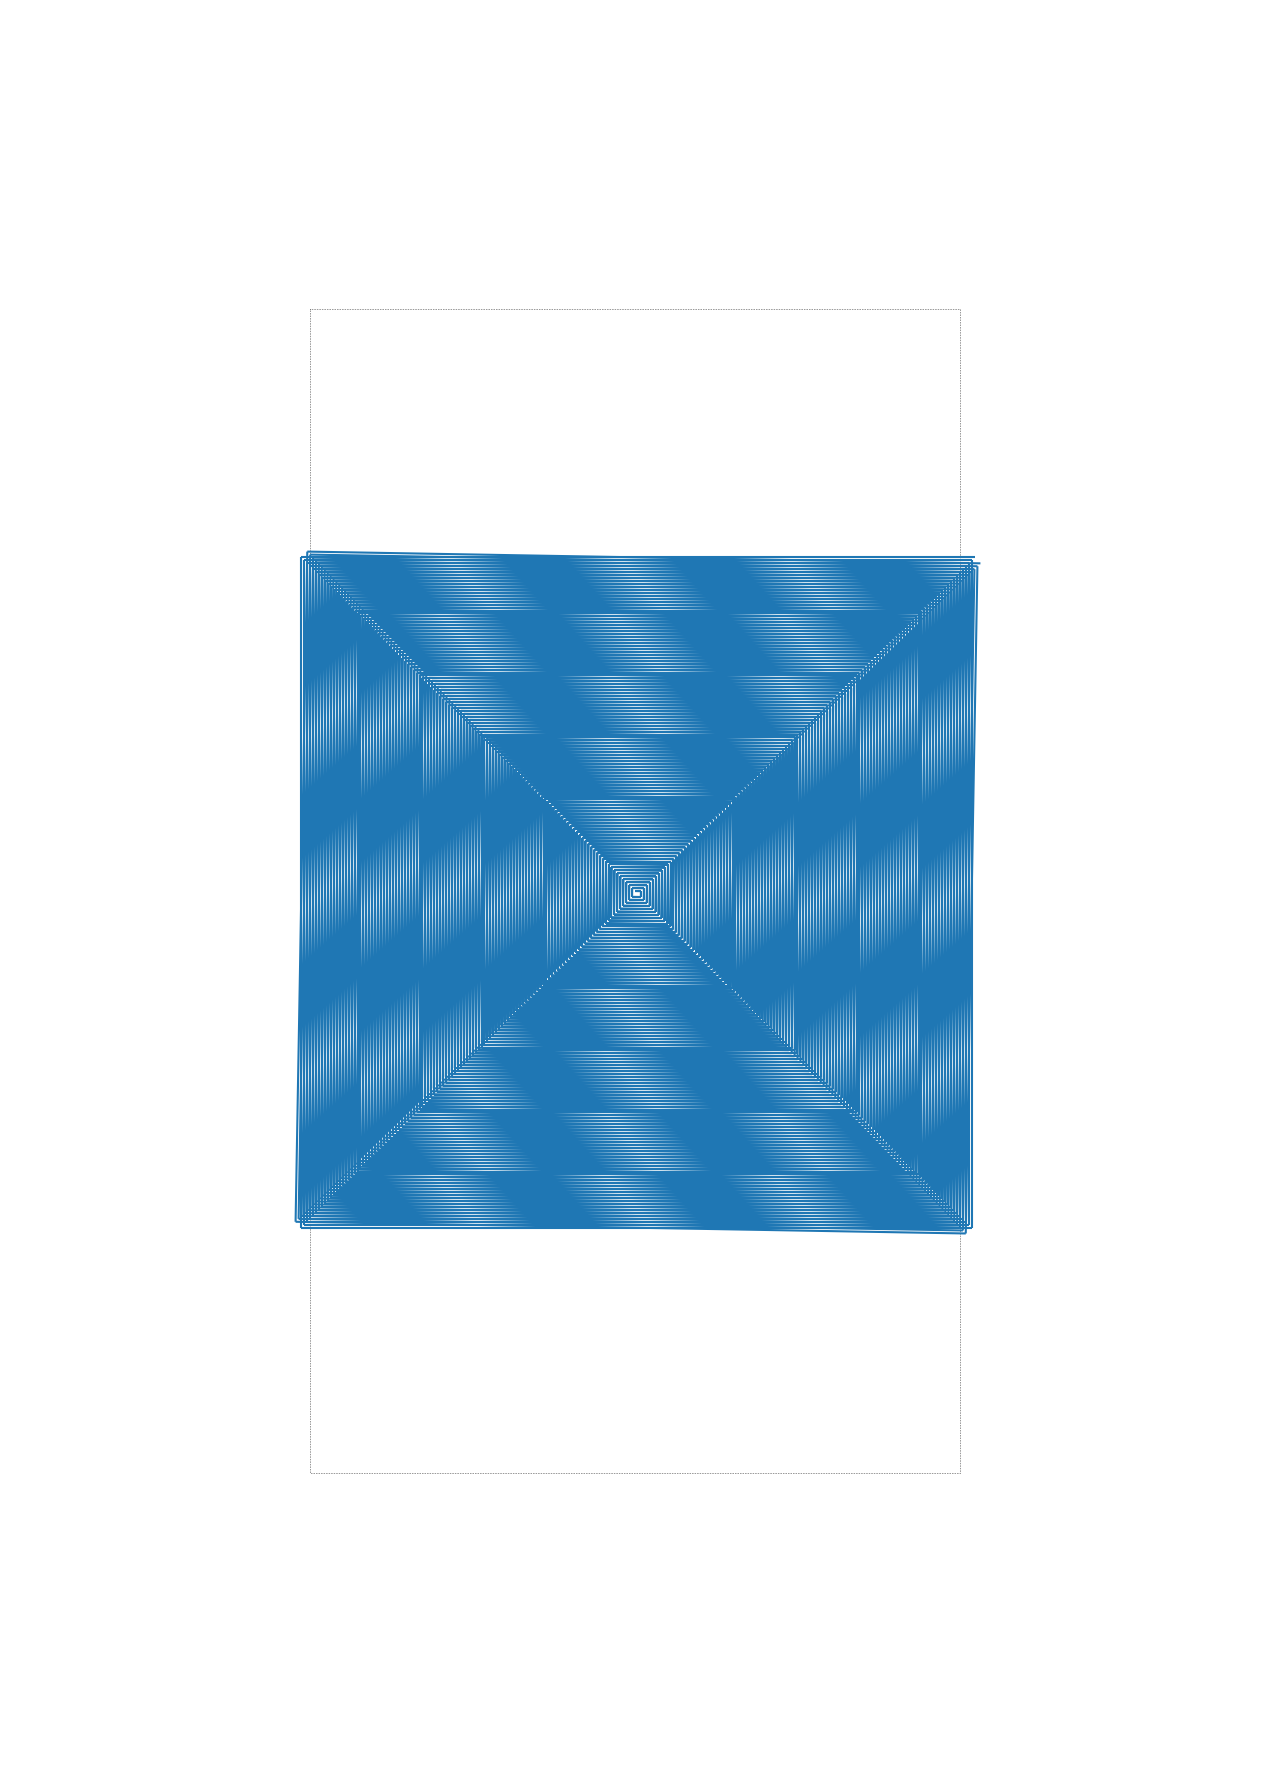

Saved:
07_moire/moire_square_spiral_2_A.svg
07_moire/moire_square_spiral_2_B.svg
07_moire/moire_square_spiral_2_overlay.svg
Try adjusting: margin_mm, start_step_mm, step_increment_mm, rotation_deg, line_width_mm.


In [28]:
# Archimedean square spiral moiré (A4, parametric, SVG export)
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# -----------------------------
# Parameters
# -----------------------------
# Page
W_mm = 210.0
H_mm = 297.0
margin_mm = 50.0

# Spiral geometry
start_step_mm = 1.0      # first segment length
step_increment_mm = 0.5  # increment added after every two segments
rotation_deg = 1.0       # rotation for the second spiral
max_segments = 20000     # safety cap

# Styling
line_width_mm = 1.0
alpha_a = 1.0
alpha_b = 1.0

# Output
outdir = "07_moire"
basename = "moire_square_spiral_2"
os.makedirs(outdir, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def square_spiral_segments(cx, cy, start_step, step_inc, radius_limit, max_segs=20000):
    """
    Build axis aligned segments for an Archimedean square spiral.
    Segment lengths increase linearly: L, L, L+inc, L+inc, L+2inc, L+2inc, ...
    """
    dirs = [(1,0), (0,1), (-1,0), (0,-1)]  # right, up, left, down
    x, y = cx, cy
    segs = []
    L = start_step
    d_idx = 0
    leg_count = 0

    for k in range(max_segs):
        dx, dy = dirs[d_idx]
        x2 = x + dx * L
        y2 = y + dy * L
        segs.append([[x, y], [x2, y2]])
        x, y = x2, y2

        # Stop if we are clearly outside the drawable region
        if max(abs(x - cx), abs(y - cy)) > radius_limit + 2 * max(start_step, step_inc):
            break

        d_idx = (d_idx + 1) % 4
        leg_count += 1
        if leg_count % 2 == 0:
            L += step_inc

    return np.array(segs, dtype=float)

def rotate_segments(segments, angle_deg, cx, cy):
    if angle_deg == 0:
        return segments
    theta = math.radians(angle_deg)
    c, s = math.cos(theta), math.sin(theta)
    segs = segments.copy().reshape(-1, 2)
    segs[:,0] -= cx
    segs[:,1] -= cy
    x_new = c * segs[:,0] - s * segs[:,1]
    y_new = s * segs[:,0] + c * segs[:,1]
    segs[:,0], segs[:,1] = x_new + cx, y_new + cy
    return segs.reshape(-1, 2, 2)

def mm2in(x_mm):
    return x_mm / 25.4

# -----------------------------
# Build geometry
# -----------------------------
cx, cy = W_mm / 2.0, H_mm / 2.0
radius_limit = min(W_mm, H_mm) / 2.0 - margin_mm

segs_a = square_spiral_segments(cx, cy, start_step_mm, step_increment_mm, radius_limit, max_segments)
segs_b = rotate_segments(segs_a, rotation_deg, cx, cy)

# -----------------------------
# Plot preview
# -----------------------------
fig = plt.figure(figsize=(mm2in(W_mm), mm2in(H_mm)), dpi=150)
ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, W_mm)
ax.set_ylim(0, H_mm)
ax.invert_yaxis()  # origin at top left, like a page
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Draw margins for reference
ax.add_patch(plt.Rectangle((margin_mm, margin_mm),
                           W_mm - 2*margin_mm, H_mm - 2*margin_mm,
                           fill=False, linewidth=0.3, linestyle=":"))

# Add both spirals
lw = line_width_mm  # matplotlib uses data units here, so mm works directly
lc_a = LineCollection(segs_a, linewidths=lw, alpha=alpha_a, joinstyle='miter', capstyle='butt')
lc_b = LineCollection(segs_b, linewidths=lw, alpha=alpha_b, joinstyle='miter', capstyle='butt')
ax.add_collection(lc_a)
ax.add_collection(lc_b)

plt.tight_layout(pad=0)

# -----------------------------
# Save SVGs
# -----------------------------
# Individual layers
fig_a = plt.figure(figsize=(mm2in(W_mm), mm2in(H_mm)), dpi=150)
axa = plt.gca()
axa.set_aspect("equal", adjustable="box")
axa.set_xlim(0, W_mm); axa.set_ylim(0, H_mm); axa.invert_yaxis()
axa.set_xticks([]); axa.set_yticks([]); [sp.set_visible(False) for sp in axa.spines.values()]
axa.add_collection(LineCollection(segs_a, linewidths=lw, joinstyle='miter', capstyle='butt'))
fig_a.savefig(os.path.join(outdir, f"{basename}_A.svg"), bbox_inches="tight", pad_inches=0)
plt.close(fig_a)

fig_b = plt.figure(figsize=(mm2in(W_mm), mm2in(H_mm)), dpi=150)
axb = plt.gca()
axb.set_aspect("equal", adjustable="box")
axb.set_xlim(0, W_mm); axb.set_ylim(0, H_mm); axb.invert_yaxis()
axb.set_xticks([]); axb.set_yticks([]); [sp.set_visible(False) for sp in axb.spines.values()]
axb.add_collection(LineCollection(segs_b, linewidths=lw, joinstyle='miter', capstyle='butt'))
fig_b.savefig(os.path.join(outdir, f"{basename}_B.svg"), bbox_inches="tight", pad_inches=0)
plt.close(fig_b)

# Overlay
fig.savefig(os.path.join(outdir, f"{basename}_overlay.svg"), bbox_inches="tight", pad_inches=0)

plt.show()

# -----------------------------
# Notes for tuning
# -----------------------------
print("Saved:",
      os.path.join(outdir, f"{basename}_A.svg"),
      os.path.join(outdir, f"{basename}_B.svg"),
      os.path.join(outdir, f"{basename}_overlay.svg"),
      sep="\n")
print("Try adjusting: margin_mm, start_step_mm, step_increment_mm, rotation_deg, line_width_mm.")


Source: file
Saved: 07_moire/einstein_lines.svg and 07_moire/einstein_zigzag.svg


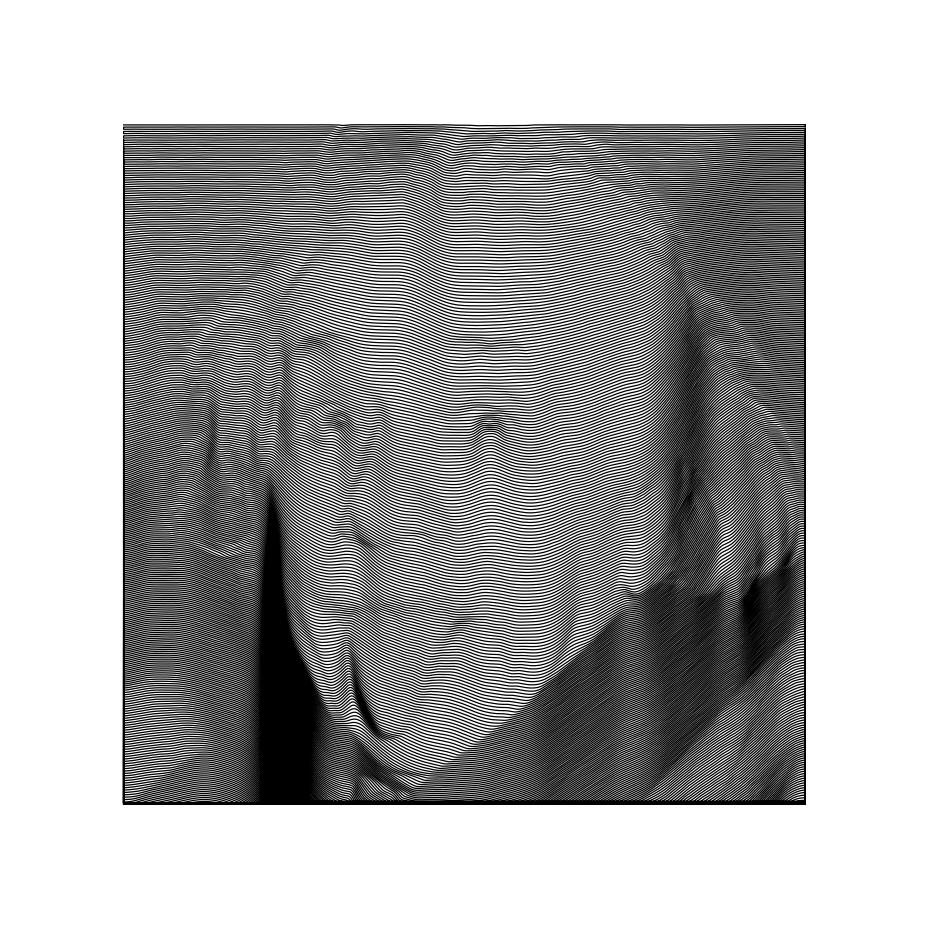

In [44]:
# Einstein halftone with stable phase regularization
# After each row, smooth phi(x) with a Gaussian and recenter to preserve mean increment.
# Then connect all iso-phase lines into one zigzag polyline with vertical edge connectors.

import os, io, requests, pathlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from scipy import ndimage as ndi

# -------- inputs --------
IMG_URL  = "https://upload.wikimedia.org/wikipedia/commons/6/6f/Albert_Einstein_sticks_his_tongue.jpg"
IMG_PATH = "Albert_Einstein_sticks_his_tongue.jpg"

W_mm, H_mm = 150.0, 150.0
margin_mm  = 18.0

s_black, s_white = 0.3, 0.6
s_min_eff, s_max_eff = 0.26, 0.70

dx_mm, dy_mm = 0.30, 0.30
smooth_px, gamma = 0.3, 0.95

sigma_phi_cols_mm = 0.3   # Gaussian sigma in mm along x for phase smoothing per row
stroke_mm = 0.15

outdir = "07_moire"; os.makedirs(outdir, exist_ok=True)
svg_path_lines = os.path.join(outdir, "einstein_lines.svg")
svg_path_zigzag = os.path.join(outdir, "einstein_zigzag.svg")

# -------- image --------
def load_grayscale(h, w):
    if IMG_PATH and pathlib.Path(IMG_PATH).expanduser().exists():
        img = Image.open(str(pathlib.Path(IMG_PATH).expanduser())).convert("L"); src="file"
    else:
        r = requests.get(IMG_URL, timeout=10); r.raise_for_status()
        img = Image.open(io.BytesIO(r.content)).convert("L"); src="url"
    img = ImageOps.exif_transpose(img)
    ww, hh = img.size; side = min(ww, hh)
    left = (ww - side)//2; top = (hh - side)//2
    img = img.crop((left, top, left+side, top+side)).resize((w, h), Image.BILINEAR)
    return np.asarray(img, np.float32)/255.0, src

# -------- grid --------
x_min, x_max = margin_mm, W_mm - margin_mm
y_min, y_max = margin_mm, H_mm - margin_mm
Xs = np.arange(x_min, x_max + 1e-9, dx_mm)
Ys = np.arange(y_min, y_max + 1e-9, dy_mm)
NX, NY = len(Xs), len(Ys)

I, src = load_grayscale(NY, NX)
print("Source:", src)

# preprocess
if smooth_px > 0:
    I = ndi.gaussian_filter(I, smooth_px)
I = (I - I.min()) / max(1e-6, I.max()-I.min())
I = (1.0 - I)**gamma
blur = ndi.gaussian_filter(I, 1.2)
I = np.clip(I + 0.6*(I - blur), 0, 1)

S = s_black + (s_white - s_black) * (1.0 - I)
S = ndi.gaussian_filter(S, sigma=(0.0, 0.8))
S = np.clip(S, s_min_eff, s_max_eff)

# -------- stable phase integration with per-row smoothing and mean preservation --------
two_pi = 2*np.pi
omega = two_pi / S
phi = np.zeros_like(S)

sigma_cols = max(0.0, sigma_phi_cols_mm / max(dx_mm, 1e-6))  # convert mm to columns
for k in range(NY-1):
    dphi = dy_mm * omega[k, :]
    phi_next = phi[k, :] + dphi
    if sigma_cols > 0:
        phi_next = ndi.gaussian_filter1d(phi_next, sigma=sigma_cols, mode="nearest")
    target_mean = dy_mm * np.mean(omega[k, :])
    actual_mean = np.mean(phi_next - phi[k, :])
    phi[k+1, :] = phi_next + (target_mean - actual_mean)

# -------- iso-phase polylines --------
phi_max = phi[-1, :]
n_max = int(np.floor(np.nanmax(phi_max) / two_pi))
levels = two_pi * np.arange(1, n_max + 1)

def interp_y_for_level(phi_col, level, Ys):
    idx = np.searchsorted(phi_col, level)
    idx = np.clip(idx, 1, len(phi_col) - 1)
    y0, y1 = Ys[idx-1], Ys[idx]
    p0, p1 = phi_col[idx-1], phi_col[idx]
    w = np.clip((level - p0) / (p1 - p0 + 1e-9), 0.0, 1.0)
    return y0 + w * (y1 - y0)

polylines = []  # each is (xs, ys) with no NaNs
for lev in levels:
    ys = np.array([interp_y_for_level(phi[:, ix], lev, Ys) for ix in range(NX)])
    xs = Xs.copy()
    mask = (ys >= y_min) & (ys <= y_max)
    if not np.any(mask):
        continue
    xs[~mask] = np.nan; ys[~mask] = np.nan
    good = ~np.isnan(xs) & ~np.isnan(ys)
    start = None
    for i in range(NX):
        if good[i] and start is None: start = i
        if (i == NX-1 or not good[i+1]) and start is not None:
            end = i + 1
            if end - start > 2:
                polylines.append((xs[start:end], ys[start:end]))
            start = None

# -------- build single zigzag path --------
# Idea: draw line 0 left->right, extend to right edge,
# connect vertically along the right edge to next line's y,
# draw line 1 right->left, extend to left edge, connect vertically, and so on.

def build_zigzag_path(lines, x_left, x_right):
    pts_x, pts_y = [], []
    for i, (xs, ys) in enumerate(lines):
        # direction
        left_to_right = (i % 2 == 0)
        if not left_to_right:
            xs = xs[::-1]; ys = ys[::-1]

        # ensure we start from the near edge with a short horizontal stub
        edge_x = x_left if not left_to_right else x_right
        start_edge_x = x_left if left_to_right else x_right
        # prepend a point at the starting edge to make a clean connector
        pts_x.append(start_edge_x); pts_y.append(ys[0])
        # now the line itself
        pts_x.extend(xs.tolist()); pts_y.extend(ys.tolist())
        # extend to the far edge to land exactly on edge
        pts_x.append(edge_x); pts_y.append(ys[-1])

        # connector to the next line (vertical along the current edge)
        if i < len(lines) - 1:
            next_y = lines[i+1][1][0] if (i % 2 == 0) else lines[i+1][1][-1]
            pts_x.append(edge_x); pts_y.append(next_y)
    return np.array(pts_x), np.array(pts_y)

# Sort lines by their median y so the path goes top to bottom
polylines_sorted = sorted(polylines, key=lambda p: float(np.nanmedian(p[1])))
zig_x, zig_y = build_zigzag_path(polylines_sorted, x_min, x_max)

# -------- SVG writers --------
def svg_preamble(w_mm, h_mm):
    return (f'<svg xmlns="http://www.w3.org/2000/svg" width="{w_mm}mm" height="{h_mm}mm" '
            f'viewBox="0 0 {w_mm} {h_mm}">\n'
            f'  <rect x="0" y="0" width="{w_mm}" height="{h_mm}" fill="white"/>\n')
def svg_footer(): return '</svg>\n'
def polyline_tag(xs, ys, sw=stroke_mm, color="black"):
    pts = " ".join([f"{x:.3f},{y:.3f}" for x, y in zip(xs, ys)])
    return f'  <polyline fill="none" stroke="{color}" stroke-width="{sw:.3f}" points="{pts}"/>\n'

# save separate lines (optional)
with open(svg_path_lines, "w") as f:
    f.write(svg_preamble(W_mm, H_mm))
    for xs, ys in polylines_sorted:
        f.write(polyline_tag(xs, ys))
    f.write(svg_footer())

# save single zigzag path
with open(svg_path_zigzag, "w") as f:
    f.write(svg_preamble(W_mm, H_mm))
    f.write(polyline_tag(zig_x, zig_y))
    f.write(svg_footer())

print("Saved:", svg_path_lines, "and", svg_path_zigzag)

# -------- preview --------
plt.figure(figsize=(W_mm/25.4, H_mm/25.4), dpi=160)
plt.plot(zig_x, zig_y, linewidth=stroke_mm/0.264583, color="black")
plt.xlim(0, W_mm); plt.ylim(H_mm, 0); plt.axis("off"); plt.tight_layout()
plt.show()
